# Running tengri on the Apple GPU (MPS) — experimental

**Status: experimental.** This is a working recipe with measured numbers, not a
supported configuration. It needs a JAX version tengri does not pin, and it
runs in pure float32, where parts of the model are still open work (#1206).
Nothing here changes the default: on CPU, in float64, nothing below applies.

The one-line summary, measured on an Apple M4 Pro:

```text
    one galaxy at a time    ->  CPU, by 59x to 86x. Large and stable.
    ~256 galaxies a batch   ->  parity, +/-25%, whichever shape you measure.
    never assume, measure   ->  MPS run-to-run spread exceeds the effect size.
```

There is no throughput reason to move tengri to the Apple GPU on this hardware.
The honest reasons are compile time (~10x faster) and curiosity.

The reason is not that the GPU is slow. It is that tengri moves a lot of memory
and does very little arithmetic — about **0.12 FLOP per byte** on the
`WavePrecomp` path. A GPU needs roughly 25–50 FLOP/byte before its ALUs matter.
So per galaxy there is nothing for the GPU to win with; the only way it wins is
by having enough galaxies in flight to hide its dispatch latency.

**Two warnings about the numbers in this notebook**, both learned by getting
them wrong first:

1. **MPS timings are not reproducible to better than ~2x.** The same script,
   same batch, run twice, gave 0.28 and 0.67 ms/galaxy. CPU was stable to ~6%
   over the same period. Absolute MPS numbers here are illustrative; the
   *ratios* measured side by side in one sitting are what to trust, and even
   those move with what else the machine is doing.
2. **Benchmark one shape per process.** Running forward, gradient and a fit in
   a single process makes the later ones look worse. That contamination alone
   flipped a conclusion for me.

## 1. Install

The backend is [`jax-mps`](https://github.com/tillahoffmann/jax-mps), a
community PJRT plugin built on MLX. It is not Apple's `jax-metal`, which last
released in October 2024.

**Use a separate environment.** `jax-mps` pins a JAX version that tengri's main
environment does not use, and you do not want to move JAX under your working
installation.

```bash
python3.12 -m venv ~/.venvs/tengri-mps
source ~/.venvs/tengri-mps/bin/activate
pip install "jax>=0.10,<0.11" "jaxlib>=0.10,<0.11" "jax-mps==0.10.10"
pip install -e /path/to/tengri
```

Version constraints, because they are tighter than they look:

| you have | you need |
|---|---|
| Python 3.12 | `jax-mps` 0.10.10 → **jax 0.10.x** |
| jax 0.9.x | `jax-mps` 0.9.9 → **Python 3.13** (cp313-only wheel) |

Either JAX or Python has to move from tengri's usual pairing. There is no
combination that leaves both where they are.

## 2. The two rules

**Rule 1 — MPS has no float64, at all.** Not "slower"; absent. A float64 array
does not get downcast, it raises:

```text
MLX does not support float64 (F64).
```

That is a good failure mode — loud, not silent — but it means the whole process
must be float32.

**Rule 2 — select float32 in the environment, before Python starts.** Setting
it after `import tengri` is too late: constants allocated during the import are
already on the device.

```bash
export JAX_ENABLE_X64=0
export JAX_PLATFORMS=mps
```

tengri honors that (#1840) and holds it for the whole import (#1880). It will
warn once that you are in float32 and that cosmological distances are the known
hazard — that warning is expected here, not a problem.

Optional, and worth setting: `JAX_MPS_ASYNC_DISPATCH=1`. Measured, it cut cold
compile from 8.1 s to 0.60 s. It changes warm time very little.

In [1]:
import os

# Must be set before jax/tengri are imported. In a notebook that means the very
# first cell, before any other import touches JAX.
os.environ["JAX_ENABLE_X64"] = "0"
os.environ["JAX_PLATFORMS"] = "mps"
os.environ["JAX_MPS_ASYNC_DISPATCH"] = "1"

import jax
import jax.numpy as jnp
import numpy as np

import tengri

print("device :", jax.devices())
print("x64    :", jax.config.jax_enable_x64)
print("dtype  :", jnp.zeros(1).dtype)

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_39096/2571388136.py:13: UserWarning: JAX_ENABLE_X64=0: tengri is honoring your request for float32 and is NOT enabling 64-bit precision. Cosmological distances are the known hazard — d_L^2 at z > 0.01 overflows float32 — so any code that forms d_L^2 directly will produce inf. tengri's own projection avoids it by applying (1+z)/(4*pi*d_L^2) as a log10 offset, but third-party code may not. Unset JAX_ENABLE_X64 to restore the float64 default.
  import tengri
Platform 'mps' is experimental and not all JAX functionality may be correctly supported!


[jax-mps] JAX_MPS_ASYNC_DISPATCH is ON: async dispatch enabled — may be much faster, but experimental and may break. Unset it for safe synchronous execution.


device : [MpsDevice(id=0)]
x64    : False
dtype  : float32


You should see `[MpsDevice(id=0)]`, `False`, `float32`. If `x64` is `True`,
something imported JAX before the `os.environ` lines ran — restart the kernel
and put that cell first.

## 3. Predicting on the GPU

Nothing about the model API changes. Build and predict exactly as on CPU.

In [2]:
from tengri import FIXED, FREE, SEDModel, Uniform, load_ssp
from tengri.observation import Observation, Photometry

# load_ssp resolves a short alias and walks parent dirs for data/, so this works
# whatever the working directory is. Do not hand-build a cwd-relative data/...
# path in a notebook: it only resolves from the repo root, and the executor
# runs from notebooks/.
ssp = load_ssp("prsc_miles_chabrier_wNE")
obs = Observation(
    photometry=Photometry.from_names(
        ["galex_fuv", "sdss_u", "sdss_g", "sdss_r", "wise_w1", "wise_w4"]
    )
)

model = SEDModel.build(
    ssp_data=ssp,
    observation=obs,
    sfh={"type": "dpl", "all_params": FREE},
    dust={"law": "power_law", "type": "two_component", "all_params": FIXED},
    redshift=Uniform(0.01, 2.0, "redshift"),
    approx=tengri.WavePrecomp(),  # the path fits use; also the cheaper one here
)

params = model.spec.sample(jax.random.PRNGKey(0))
flux = model.predict_photometry(params)

print("photometry [erg/s/cm2/Hz]:", np.asarray(flux))
print("on device                :", flux.devices())
print("dtype                    :", flux.dtype)

src/tengri/components/stellar/sps/dsps_wrapper.py:298: UserWarning: 'ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5' is a wNE (with-Nebular-Emission) SSP: nebular continuum and lines are already baked into the templates at fixed logU/logZ_gas. Pair it with the default baked-in nebular backend only — adding neb={'type': 'cue'} or a CLOUDY grid on top double-counts nebular emission.
  return load_ssp_data(str(candidate))
src/tengri/forward/sed_model.py:8398: WildcardPartialFreeWarning: 'all_params: FREE' freed 6 of 8 parameters in group 'sfh'. These have no declared prior, only Fixed defaults, so they stay pinned:
  met_alpha_fe, met_logzsol_scatter
The fit will run with that physics held constant. Pass explicit priors for the ones you meant to vary, e.g. sfh={'met_alpha_fe': Uniform(lo, hi)}, or filter WildcardPartialFreeWarning if this is deliberate.
  spec = parse_groups(**groups)


src/tengri/forward/sed_model.py:2659: BakedInNebularWarning: BakedInBackend: nebular emission is baked into the SSP file at a FIXED logU and FIXED escape fraction determined when the SSP grid was generated (commonly logU = −3, but depends on the SSP file). The ionization parameter and escape fraction are NOT free parameters — varying neb_logU or neb_fesc in your Parameters will have no effect. Check your SSP file's nebular assumptions. Switch to CloudyGridBackend or CueBackend to vary nebular properties. To suppress when building via SEDModel.build: warnings.filterwarnings('ignore', message='BakedInBackend: nebular emission is baked'). (ionizing_source_warning='suppress' also works, but it is a BakedInBackend(...) constructor argument and the build grammar does not forward it.)
  self._nebular_backend = BakedInBackend()


photometry [erg/s/cm2/Hz]: [3.4164444e-30 9.0728145e-30 1.9072680e-29 2.7894017e-29 3.2605323e-29
 5.6344176e-29]
on device                : {MpsDevice(id=0)}
dtype                    : float32


## 4. Batching: the only thing that moves the needle

A single galaxy is the worst case for MPS by a wide margin. Batching with
`jax.vmap` closes most of that gap — and on a quiet machine can reverse it.
This is the same call, mapped over a leading axis.

In [3]:
import time


def timed(fn, arg, reps=5):
    """Warm-time a jitted callable. Returns milliseconds per call."""
    jitted = jax.jit(fn)
    jax.block_until_ready(jitted(arg))  # compile
    t0 = time.perf_counter()
    for _ in range(reps):
        jax.block_until_ready(jitted(arg))
    return (time.perf_counter() - t0) / reps * 1e3


def grad_one(p):
    return jax.grad(lambda q: jnp.sum(model.predict_photometry(q)))(p)


# A smoke check, not the measurement: batch 256 needs several GB and will kill
# the kernel on a loaded machine. The tables below carry the full sweep.
for n in (1, 32):
    batch = {k: jnp.broadcast_to(v, (n, *jnp.shape(v))) for k, v in params.items()}
    ms = timed(jax.vmap(grad_one), batch) if n > 1 else timed(grad_one, params)
    print(f"batch={n:4d}  total={ms:7.2f} ms   per galaxy={ms / n:6.3f} ms")

batch=   1  total= 110.03 ms   per galaxy=110.032 ms


batch=  32  total=  91.28 ms   per galaxy= 2.853 ms


### Measured, M4 Pro, float32, `WavePrecomp`, 6 bands

Gradient of `sum(predict_photometry)`, warm, 10 reps:

| batch | CPU per galaxy | MPS per galaxy | faster |
|---|---|---|---|
| 1 | **0.79 ms** | 46.65 ms | CPU 59x |
| 8 | **0.41** | 6.64 | CPU 16x |
| 32 | **0.30** | 1.83 | CPU 6.1x |
| 128 | **0.30** | 0.55 | CPU 1.8x |
| 256 | 0.31 | **0.28** | MPS — crossover |
| 512 | 0.31 | **0.18** | MPS 1.7x |

MPS total time is almost flat in batch size: **46.7 ms at n=1, 94.4 ms at
n=512**, for 512x the work. It is nearly all fixed overhead. CPU is linear. So
the question is never "is the GPU fast" — it is "do you have enough galaxies to
amortize ~46 ms of dispatch".

**That table is one run and the crossover in it is not a constant.** Repeating
the identical script at batch 256 across independent processes, on a busier
machine:

| | runs [ms/galaxy] | median |
|---|---|---|
| CPU | 0.70, 0.62, 0.60, 0.52 | 0.61 |
| MPS | 0.43, 0.42, 0.35, 0.35 | 0.385 |

Same batch size, but every number roughly doubled versus the first table
because the machine was under load. The *direction* held; the values did not.
Treat "a few hundred galaxies" as the scale at which this becomes worth
measuring on your own machine — not as a threshold you can inherit.

**Compile time favors MPS heavily** — cold 0.34–0.71 s against CPU's 4.6–5.1 s.
For iterating on a model that is a real gain regardless of throughput.

### It depends on the SHAPE of the work — but less than you would think

"Prediction on the GPU, inference on the CPU" is the natural intuition. The
data does not support it, and it also does not support the opposite. Batch 256,
one shape per process, 3–4 independent runs each:

| shape | CPU [ms/gal] | MPS [ms/gal] | MPS/CPU |
|---|---|---|---|
| **A** forward `predict_photometry` | 0.288, 0.304, 0.290 | 0.296, 0.353, 0.314 | 1.08 |
| **B** gradient `grad(sum(predict))` | 0.577, 0.484, 0.571 | 0.497, 0.434, 0.370 | **0.76** |
| **C** inference: 50 scanned grad steps | 0.397, 0.389, 0.373 | 0.537, 0.530, 0.355, 0.363 | 1.15 |

**All three sit within ±25% of parity, and MPS's own run-to-run spread is
larger than the gaps between them** — shape C ranges 0.355–0.537 ms, about 51%,
while CPU holds to ~5%. With this many replicates the shape ordering is simply
not resolvable, with one exception:

**The gradient is MPS's best case.** It is the only shape where MPS beat CPU in
every replication. That is consistent with the arithmetic-intensity argument —
the reverse pass does more work per byte already moved than the forward pass
does — but the margin is small.

An earlier version of this notebook claimed forward prediction was MPS's
*worst* case at ~2.1x slower. That came from two runs and did not replicate;
it is 1.08x here. Both that claim and the original "MPS wins from ~250" were
over-read from too few samples. What survives replication is narrower:

```text
  one galaxy      ->  CPU wins by 59x (gradient) to 86x (MAP fit). Large, stable.
  ~256 a batch    ->  parity, +/-25%, with MPS noise exceeding the shape differences.
  gradient shape  ->  MPS's best case, consistently, by a small margin.
```

On this hardware there is no throughput reason to move to the GPU. The
defensible reasons are the compile time (§4) and curiosity.

### The same numbers, as a picture

Two views of one dataset. Left: per-galaxy cost — where the lines cross is the
only number that decides which backend to use. Right: total wall clock — MPS is
nearly horizontal, which is the whole explanation.

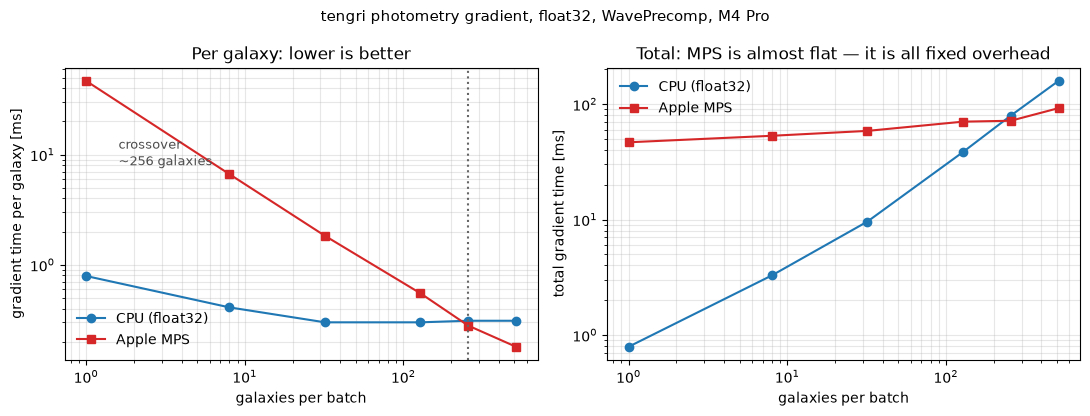

In [4]:
import matplotlib.pyplot as plt

BATCH = np.array([1, 8, 32, 128, 256, 512])
CPU_PER = np.array([0.79, 0.41, 0.30, 0.30, 0.31, 0.31])  # ms per galaxy
MPS_PER = np.array([46.65, 6.64, 1.83, 0.55, 0.28, 0.18])
CPU_TOT = CPU_PER * BATCH
MPS_TOT = MPS_PER * BATCH

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

ax1.loglog(BATCH, CPU_PER, "o-", label="CPU (float32)", color="#1f77b4")
ax1.loglog(BATCH, MPS_PER, "s-", label="Apple MPS", color="#d62728")
cross = BATCH[np.argmax(MPS_PER < CPU_PER)]
ax1.axvline(cross, ls=":", color="0.4")
ax1.annotate(
    f"crossover\n~{cross} galaxies",
    xy=(cross, 1.0),
    xytext=(1.6, 8),
    fontsize=9,
    color="0.3",
)
ax1.set_xlabel("galaxies per batch")
ax1.set_ylabel("gradient time per galaxy [ms]")
ax1.set_title("Per galaxy: lower is better")
ax1.legend(frameon=False)
ax1.grid(alpha=0.3, which="both")

ax2.loglog(BATCH, CPU_TOT, "o-", label="CPU (float32)", color="#1f77b4")
ax2.loglog(BATCH, MPS_TOT, "s-", label="Apple MPS", color="#d62728")
ax2.set_xlabel("galaxies per batch")
ax2.set_ylabel("total gradient time [ms]")
ax2.set_title("Total: MPS is almost flat — it is all fixed overhead")
ax2.legend(frameon=False)
ax2.grid(alpha=0.3, which="both")

fig.suptitle("tengri photometry gradient, float32, WavePrecomp, M4 Pro", fontsize=11)
fig.tight_layout()
plt.show()

The right-hand panel is the point. MPS goes from 46.7 ms to 94.4 ms while doing
512x more work; CPU goes from 0.8 ms to 158 ms. The GPU is not getting faster
as N grows — it is finally being given enough work to be worth waking up.

## 5. Fitting on MPS

Forward prediction working tells you nothing about fitting: that runs through
`Fitter` → `InferenceContext` → a backend, with its own compiled kernels. It
does work. Whether you *want* it to is another matter.

Note what `Fitter` does to `approx` — it resolves `"auto"` and **tops up** to
the LUT even though the model was built without one. Always print it; an arm
that silently lost its precompute is the classic way to benchmark the wrong
thing.

In [5]:
from tengri import Fitter

truth = model.spec.sample(jax.random.PRNGKey(0))
flux64 = np.asarray(model.predict_photometry(truth), dtype=np.float64)
sigma = 0.05 * np.abs(flux64)
data = flux64 + sigma * np.random.default_rng(0).standard_normal(flux64.shape)

fitter = Fitter(
    model,
    jnp.asarray(data, jnp.float32),
    jnp.asarray(sigma, jnp.float32),
    data_type="photometry",
)
print("resolved approx:", fitter.model.approx)  # expect wave_precomp=True, ztable=True

# Run three times: the first includes XLA compilation, the rest do not.
for i in (1, 2):
    t0 = time.perf_counter()
    posterior = fitter.run("map", n_steps=100, verbose=False)
    print(f"  MAP run {i}: {time.perf_counter() - t0:6.2f} s  (100 steps)")

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_39096/1641681367.py:8: DeprecationWarning: Fitter(sed_model, ...) is deprecated and will be removed in tengri v1.0. Inference is canonically through ForwardModel (issue #211). Replace with: forward = ForwardModel.build(sed=sed_model, observation=obs); Fitter(forward, data, noise).run(method) -- or use the shortcut forward.fit(data, noise, method=...).
  fitter = Fitter(


resolved approx: ApproxState(wave_precomp=True, ztable=True, n_subbands=5)


  MAP run 1:   7.85 s  (100 steps)


  MAP run 2:   6.99 s  (100 steps)


### Measured: single-galaxy MAP, 300 ADAM steps

| run | CPU | MPS |
|---|---|---|
| 1 (includes compile) | 4.73 s | 20.07 s |
| 2 | **0.22 s** | 18.80 s |
| 3 | **0.22 s** | 19.43 s |

Two things to read here.

**On CPU the fit is 0.22 s, not 4.7 s.** The first run is XLA compilation. With
300 gradients at 0.822 ms the arithmetic is 0.25 s, so 0.22 s warm means the
`lax.scan` optimizer loop has essentially *zero* per-step overhead. If you see
seconds, you are measuring the compile — and tengri's persistent JAX cache
(`~/.cache/tengri_jax_cache`) amortizes it across processes.

**On MPS the warm time does not improve.** 19 s is execution, not compile:
~63 ms per scan step against CPU's 0.73 ms. A single-galaxy fit is 300
sequential steps, each one a dispatch — the worst possible shape for this
backend, and **86x slower**.

So: **do not fit one galaxy on the GPU.**

Does batching rescue it? Partly. Shape C in §4 is exactly this question — a
batch of 256 carried through 50 scanned gradient steps — and it lands at
**1.15x slower** than CPU, i.e. parity within the noise, while the bare
gradient at the same batch was MPS's one consistent win. A fit multiplies
per-step dispatch by the step count, so it gives back some of what batching
buys.

The honest position: a `CatalogFitter` over hundreds of galaxies with a vmapped
backend (`mcmc_nuts`, `mcmc_hmc`) is the case with the best chance, because it
is the widest. It is **not measured end to end here**, and shape C is a reason
for tempered expectations rather than optimistic ones.

## 6. Is the backend healthy?

If MPS ever looks slow at *everything*, check it against work a GPU should
obviously win. On the same machine:

| | CPU | MPS |
|---|---|---|
| matmul 4096² | 1482 GFLOP/s | **6566 GFLOP/s** |
| 200 tiny chained ops | **0.054 ms** | 0.453 ms |

That is the whole story in two rows: MPS is 4.4x faster when there is
arithmetic to do, and 8.4x slower when there is only dispatch. tengri's
per-galaxy gradient is the second kind of workload.

In [6]:
a = jnp.asarray(np.random.default_rng(0).standard_normal((2048, 2048)), jnp.float32)
mm = timed(lambda x: x @ x, a)
print(f"matmul 2048^2: {mm:.2f} ms  ->  {2 * 2048**3 / (mm * 1e-3) / 1e9:.0f} GFLOP/s")

matmul 2048^2: 3.49 ms  ->  4928 GFLOP/s


## 7. Limits, honestly

* **float32 only.** #1206 tracks what is still open there. Forward photometry
  and gradients on the fit objective agree with float64 to ~1e-5 on the
  configurations measured so far, but that is not the whole model.
* **Single device.** MPS is one GPU; there is no sharding to do.
* **JAX version drift.** `jax-mps` tracks JAX closely and pins a narrow range.
  Expect to bump both together.
* **Not in CI.** Nothing here is covered by the test suite. Treat results as
  experimental and check anything important against a CPU float64 run.

For a fit that must be right, use the default: CPU, float64. This path is for
large batches and for iterating quickly, not for final science.